# Lab: Telco Customer Churn Prediction
**Author:** Gordan  
**Role:** Machine Learning Intern  

---

## 1. Scenario & Background
Customer churn occurs when subscribers stop doing business with a service provider. In the highly competitive telecommunications sector, acquiring new customers costs significantly more than retaining existing ones. 

The objective of this project is to build a predictive machine learning pipeline using a **K-Nearest Neighbors (KNN)** classifier. By identifying high-risk customers before they defect, the business can deploy targeted retention strategies to protect revenue.

### Learning Objectives
* **Data Auditing:** Identify and resolve structural defects (e.g., string-to-numeric anomalies, missing data values).
* **Feature Engineering:** Transform mixed categorical feature fields into numeric dimensions using One-Hot Encoding.
* **Feature Scaling:** Synchronize measurement scales to eliminate metric space distortions during distance calculation.
* **Optimization:** Evaluate a spectrum of hyperparameter configurations ($K$-values) to find the optimal trade-off between Precision and Recall.

---

## 2. Dataset Overview
* **Source:** Kaggle Telco Customer Churn Dataset
* **Instance Count:** 7,043 customers
* **Feature Scope:** 20 predictor columns (demographics, signed services, account metrics)
* **Target Variable:** `Churn` (Yes / No)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the Telco Churn dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Data Types Overview ===")
print(df.dtypes)

print("\n=== Target Class Distribution ===")
print(df['Churn'].value_counts())

# 1. Drop customerID since it's just an arbitrary tracker
df.drop('customerID', axis=1, inplace=True)

# 2. Convert TotalCharges to numeric. 'coerce' turns hidden blank spaces into NaN (missing values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Check how many missing values were created from those blank spaces
print(f"Missing values found in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 4. Fill those missing values with the median of the column so the model doesn't crash
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("\n=== Cleaned Numerical Columns ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

# Step 2: Data Preprocessing - Encoding Categorical Variables

# 1. Map target variable 'Churn' to binary numeric values: Yes = 1, No = 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 3. Convert all categorical text columns into numeric indicators
# drop_first=True prevents multicollinearity (the dummy variable trap)
X = pd.get_dummies(X, drop_first=True)

# 4. Ensure all resulting columns are numeric integers/floats instead of booleans
X = X.astype(float)

print("=== Encoding Complete ===")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")



=== Dataset Shape ===
(7043, 21)

=== Data Types Overview ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Target Class Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Missing values found in TotalCharges: 11

=== Cleaned Numerical Columns ===
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
=== Encoding Complete ===
Features shape (X): (7043, 30)
Target shape (y): (7

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. Scale the features
# Fit on training data ONLY to prevent data leakage, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Splitting & Scaling Complete ===")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

=== Splitting & Scaling Complete ===
Training features shape: (5634, 30)
Testing features shape: (1409, 30)


In [40]:
# Calculate correlation of each feature with churn
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

# Keep only features with correlation > 0.1 (arbitrary threshold, you can adjust)
selected_features = correlations[correlations > 0.1].index.tolist()

print("=== Feature Selection ===")
print(f"Features with correlation > 0.1: {len(selected_features)}")
print(correlations)

# Filter both train and test to keep only these features
X_train_selected = X_train_scaled[:, [X_train.columns.get_loc(col) for col in selected_features]]
X_test_selected = X_test_scaled[:, [X_train.columns.get_loc(col) for col in selected_features]]

print(f"\nOriginal features: {X_train_scaled.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

=== Feature Selection ===
Features with correlation > 0.1: 21
tenure                                   0.345593
InternetService_Fiber optic              0.312656
PaymentMethod_Electronic check           0.309214
Contract_Two year                        0.302209
InternetService_No                       0.228929
OnlineSecurity_No internet service       0.228929
DeviceProtection_No internet service     0.228929
TechSupport_No internet service          0.228929
StreamingMovies_No internet service      0.228929
StreamingTV_No internet service          0.228929
OnlineBackup_No internet service         0.228929
MonthlyCharges                           0.198040
PaperlessBilling_Yes                     0.197981
TotalCharges                             0.194403
Contract_One year                        0.179467
OnlineSecurity_Yes                       0.174581
Dependents_Yes                           0.167459
TechSupport_Yes                          0.165723
Partner_Yes                           

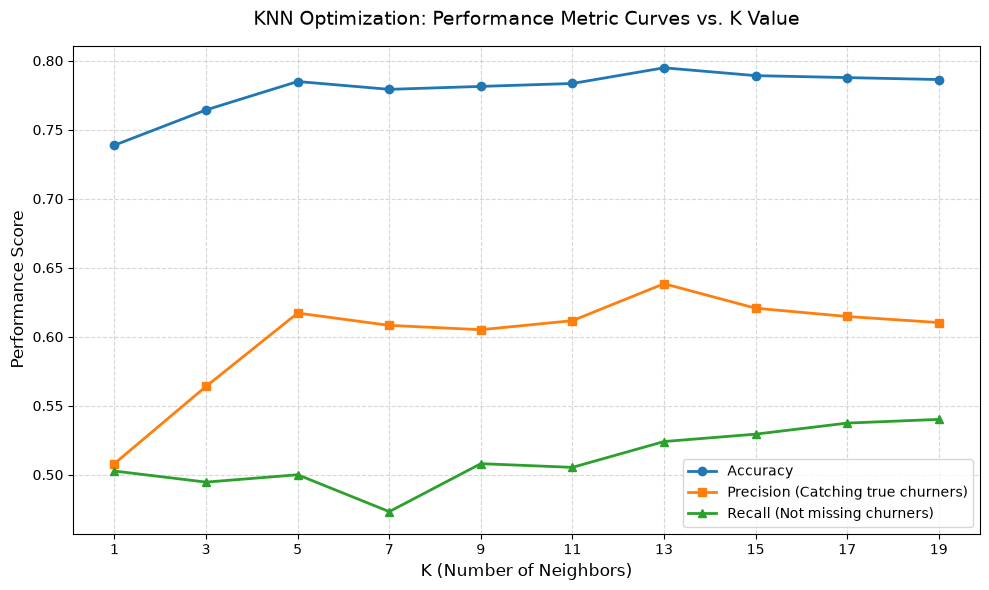

OPTIMAL CONFIGURATION
Best K Value: 19
Highest Test Accuracy: 0.7864 (78.64%)
Corresponding Precision: 0.6103
Corresponding Recall: 0.5401


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Define the range of odd K values to test
k_values = range(1, 21, 2)
accuracies = []
precisions = []
recalls = []

# 2. Iterate through K values and evaluate performance
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_selected, y_train)
    y_pred = knn.predict(X_test_selected)
    
    # Track metrics explicitly focusing on Churn (1)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, pos_label=1))

# 3. Plot the performance metrics curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, label='Accuracy')
plt.plot(k_values, precisions, marker='s', linewidth=2, label='Precision (Catching true churners)')
plt.plot(k_values, recalls, marker='^', linewidth=2, label='Recall (Not missing churners)')

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.title('KNN Optimization: Performance Metric Curves vs. K Value', fontsize=14, pad=15)
plt.xticks(k_values)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Extract and print the best K value by highest accuracy
best_index = np.argmax(recalls)
print("="*50)
print(f"OPTIMAL CONFIGURATION")
print("="*50)
print(f"Best K Value: {k_values[best_index]}")
print(f"Highest Test Accuracy: {accuracies[best_index]:.4f} ({accuracies[best_index]*100:.2f}%)")
print(f"Corresponding Precision: {precisions[best_index]:.4f}")
print(f"Corresponding Recall: {recalls[best_index]:.4f}")

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Train the final model using the optimal K value and selected features
final_knn = KNeighborsClassifier(n_neighbors=19)
final_knn.fit(X_train_selected, y_train)
y_pred_final = final_knn.predict(X_test_selected)

# 2. Print Classification Report
print("="*60)
print("FINAL CLASSIFICATION REPORT (K=19 with Feature Selection)")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=['Retained (0)', 'Churned (1)']))

# 3. Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

# 4. Display Matrix breakdown
print("="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Negatives  (Predicted Retained, Actual Retained): {cm[0][0]}")
print(f"False Positives (Predicted Churned,  Actual Retained): {cm[0][1]} <-- False Alarms")
print(f"False Negatives (Predicted Retained, Actual Churned) : {cm[1][0]} <-- Missed Churners!")
print(f"True Positives  (Predicted Churned,  Actual Churned) : {cm[1][1]}")

FINAL CLASSIFICATION REPORT (K=19 with Feature Selection)
              precision    recall  f1-score   support

Retained (0)       0.84      0.88      0.86      1035
 Churned (1)       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

CONFUSION MATRIX BREAKDOWN
True Negatives  (Predicted Retained, Actual Retained): 906
False Positives (Predicted Churned,  Actual Retained): 129 <-- False Alarms
False Negatives (Predicted Retained, Actual Churned) : 172 <-- Missed Churners!
True Positives  (Predicted Churned,  Actual Churned) : 202


In [45]:
# Check what's actually missing
df_check = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_check['TotalCharges'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')
print(df_check[df_check['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']])

      tenure  MonthlyCharges
488        0           52.55
753        0           20.25
936        0           80.85
1082       0           25.75
1340       0           56.05
3331       0           19.85
3826       0           25.35
4380       0           20.00
5218       0           19.70
6670       0           73.35
6754       0           61.90
